In [1]:
import numpy as np
import os
# Locate the data file
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 if 'unified_range_matched' in f or f.endswith('.npz'):
 print(os.path.join(root, f))


In [2]:
import numpy as np
import os
DATA = '/workspace/8925c81d-6085-49c0-af0e-ca16ef0cf52a'
Sk_F1 = np.load(os.path.join(DATA, 'Sk_F1.npy'))
t_F1 = np.load(os.path.join(DATA, 't_peaks_F1.npy'))
amp_F1 = np.load(os.path.join(DATA, 'amp_peaks_F1.npy'))
print(Sk_F1.shape, Sk_F1.dtype)
print('t range:', t_F1.min(), t_F1.max())
print('amp range:', amp_F1.min(), amp_F1.max())


(200, 8) complex128
t range: 10025.572744640449 19987.973011724418
amp range: 11.47633922777362 19.753260853328737


In [3]:
# Construct empirical M_jk for F1 (zeta).
# Each row p corresponds to a peak. S_k(t_p) is complex.
# M_jk = <S_j conj(S_k)> averaged over peaks (empirical second-moment matrix).
# This is the Hermitian peak-conditioned matrix. PC1 variance comes from this.

S = Sk_F1 # (200, 8)
# Center? In the analysis from prior work, often it's the un-centered second moment matrix.
# Let's compute both and check which gives high PC1.
M_uncent = (S.conj().T @ S) / S.shape[0] # (8,8) Hermitian
M_cent = np.cov(S.T, bias=True) # centered

def pc1_frac(M):
 w = np.linalg.eigvalsh(M)
 w = np.sort(w.real)[::-1]
 return w[0]/w.sum(), w

pc1_un, w_un = pc1_frac(M_uncent)
pc1_c, w_c = pc1_frac(M_cent)
print("Uncentered PC1 frac:", pc1_un)
print("Centered PC1 frac:", pc1_c)
print("Uncentered eigvals:", w_un)
print("Centered eigvals:", w_c)


Uncentered PC1 frac: 0.9467826521719364
Centered PC1 frac: 0.7011132874751741
Uncentered eigvals: [4.74424849e+01 1.23072135e+00 8.96859539e-01 3.23178873e-01
 1.80808955e-01 2.53509493e-02 9.74870766e-03 8.31386416e-06]
Centered eigvals: [4.61746563e+00 1.16832564e+00 3.45928971e-01 3.13814907e-01
 1.30463970e-01 9.89775058e-03 8.31387543e-06 0.00000000e+00]


In [4]:
# Note: log|S_0| is class-constant (S_0 = lambda(1) = 1, so |S_0|^2 = 1).
# log|S_7| effectively null for some functions, but for F1 we should check.
print('|S_0|^2 mean and std:', np.mean(np.abs(S[:,0])**2), np.std(np.abs(S[:,0])**2))
print('|S_7|^2 mean:', np.mean(np.abs(S[:,7])**2))
print('All k means of |Sk|^2:')
for k in range(8):
 print(f' k={k}: {np.mean(np.abs(S[:,k])**2):.4f}')


|S_0|^2 mean and std: 1.0 0.0
|S_7|^2 mean: 1.2353429239553876e-05
All k means of |Sk|^2:
 k=0: 1.0000
 k=1: 12.8038
 k=2: 23.4709
 k=3: 9.7156
 k=4: 2.4598
 k=5: 0.6318
 k=6: 0.0272
 k=7: 0.0000


In [5]:
# Plan: 
# Empirical target: M_jk = (1/P) sum_p S_j(t_p) conj(S_k(t_p)) for j,k in 0..7
# Theoretical model with resonator R(t) = sum_{q in Q} c_q q^{-it} where c_1=1, others fitted.
#
# Theoretical M_jk(R) under the "weighted moment" interpretation:
# E_R[S_j conj(S_k)] = sum_{n: omega(n)=j, n<=N} sum_{m: omega(m)=k, m<=N} 1/sqrt(n*m) * E_t[ R(t) (n/m)^{-it}? ]
# Standard mean-value calculations: E_t [ (q n / (q' m))^{-it} ] picks out diagonal q*n = q'*m.
# 
# More precisely if R(t) = sum_q c_q q^{-it}, then |R(t)|^2 weight, the "change of measure"
# E^R[ S_j conj(S_k) ] := E_t [ |R(t)|^2 S_j(t) conj(S_k)(t) ] / E_t[|R(t)|^2]
#
# S_j(t) = sum_{omega(n)=j} 1/sqrt(n) n^{-it} (over n <= N, with smooth cutoff implicit)
# conj(S_k)(t) = sum_{omega(m)=k} 1/sqrt(m) m^{it}
# |R(t)|^2 = sum_{q,q'} c_q conj(c_{q'}) (q/q')^{-it}
#
# E_t [ (q n / (q' m))^{-it} ] = delta(q n = q' m)
#
# So M_jk(R) (unnormalized) = sum_{q,q'} c_q conj(c_{q'}) sum_{n: omega=j} sum_{m: omega=k} [q n = q' m] / sqrt(n m)
# Normalization: divide by sum_{q,q'} c_q conj(c_{q'}) [q=q'] = sum_q |c_q|^2 ... 
# Wait: E_t[|R|^2] = sum_q |c_q|^2 (since cross terms have nonzero frequency).
#
# Note: empirical S has |S_0|=1 always, suggesting empirical S_j is normalized so that the j=0 component (n=1) gives 1.
# Theoretical: omega(n)=0 means n=1 only, S_0 = 1 indeed. Good.
#
# For the simple R(t) = 1 + c2 2^{-it} + c3 3^{-it} + c5 5^{-it}, Q={1,2,3,5}.
# Compute M_jk(R) using algebraic enumeration: for each pair (q, q') in Q^2, 
# we need pairs (n, m) with omega(n)=j, omega(m)=k, q*n = q'*m.
# Let's set L = lcm(q, q'), then q' divides q*n means m = q*n/q'. 
# Equivalently let g = gcd(q, q'). Then q n = q' m -> (q/g) n = (q'/g) m, with gcd(q/g, q'/g)=1.
# So m = (q/g) * (n / (q'/g)), requiring (q'/g) | n.
# Substituting: let n = (q'/g) * k, then m = (q/g) * k. So pairs are parameterized by k>=1.
# omega(n) = omega((q'/g) k), omega(m) = omega((q/g) k).
#
# We need to sum over k where the resulting n, m are <= some N. But the empirical S uses N=10^6.
# However the "theoretical" M_jk in the weighted-moment formalism corresponds to N -> infinity 
# (unconditional moments), with mollified weight. We should match conventions.
#
# Empirical |S_k|^2 means computed at peaks are FAR larger than unconditional second moments 
# (which would be ~ small powers of log log T for omega-stratified). 
# 12.8 for k=1, 23.5 for k=2 — these are HUGE. These are peak-conditioned moments.
#
# So the resonator is supposed to act like a "change of measure" that amplifies peaks.
# The theoretical claim: peaks of zeta are partially modeled by peaks of |R(t)|^2.
# Then E^R[S_j conj S_k] should approximate the empirical peak-conditioned moments.
print("Plan understood.")


Plan understood.


In [6]:
# Build M_jk(R) computation.
# For a resonator with primes Q (multiplicatively closed in support? actually we just sum over q in some set Q).
# We'll allow Q to be all squarefree products of {2,3,5} up to some bound, parameterized by c_q.
# Simplest version: Q = {1,2,3,5} with parameters c2, c3, c5 (c_1 = 1).
#
# Algorithm:
# 1. Generate all integers n <= N_R with primes only from {2,3,5}? No - n can be any positive integer.
# 2. Actually n, m can have any prime factorization. We need omega(n)=j (number of distinct primes).
# 3. The constraint q n = q' m with q, q' in Q={1,2,3,5} is hard if n, m range over all integers.
# 
# But by sparsity: m = (q/g) n / (q'/g). For arbitrary n divisible by (q'/g), we get a valid (n,m).
# We need to sum 1/sqrt(n m) = 1/sqrt(n * (q/g) n / (q'/g)) = 1/n * sqrt((q'/g)/(q/g)) = sqrt(q'/q) / n
# Wait: 1/sqrt(n*m) = 1/sqrt(n * (q/q') n) when g=gcd... let me redo:
# m = (q/g) k, n = (q'/g) k. So nm = (q q'/g^2) k^2. sqrt(nm) = sqrt(q q')/g * k.
# So 1/sqrt(nm) = g/(sqrt(q q') k).
# omega(n) = omega((q'/g) k). 
# omega(m) = omega((q/g) k).
#
# We need sum over k where omega(n)=j and omega(m)=k_idx (let me call the second index 'i' to avoid clash):
# sum_{k>=1, omega((q'/g)k)=j, omega((q/g)k)=i} 1/k
#
# This series may diverge for j=i=0 (k=1, q=q'=1 case)? Let's see: q=q'=1 means g=1, so n=k, m=k, omega(n)=omega(m).
# For j=i: sum_{k: omega(k)=j} 1/k diverges (e.g., j=0: k=1, just 1; j=1: prime powers, sum 1/p^a diverges; j=1 just gives sum_p 1/p which diverges).
# So we need a cutoff.

# In theoretical mean-value theorems, sums are typically cut off at some N (the length parameter).
# In our empirical S, N=10^6 was used. So the natural matching cutoff is N=10^6.
# 
# Let's work with cutoff N: sum over n <= N, m <= N. Then n = (q'/g) k <= N, m = (q/g) k <= N.
# So k <= min(N/(q/g), N/(q'/g)) = N * g / max(q, q').
# Equivalently k <= N / max(q/g, q'/g) = N / lcm(q,q')*g / g = N*g/lcm(q,q'). Hmm let me just say:
# k_max = floor(min(N/(q'/g), N/(q/g))) = floor(N * g / max(q, q')).

# For Q={1,2,3,5} the max(q,q') is at most 5, so k_max ~ N/5.
# We need to enumerate k up to ~N/max(q,q') which could be up to 10^6 entries, fine.
# For each k, we need omega((q'/g) k) and omega((q/g) k).

# Strategy: precompute omega(n) for n up to N using a sieve.
N = 10**6
print(f"Computing omega sieve up to N = {N}")

# Sieve for omega(n) = number of distinct prime factors
omega = np.zeros(N+1, dtype=np.int8)
for p in range(2, N+1):
 if omega[p] == 0: # p is prime
 for multiple in range(p, N+1, p):
 omega[multiple] += 1
print("omega sieve done. omega[1]=", omega[1], "omega[6]=", omega[6], "omega[30]=", omega[30])


Computing omega sieve up to N = 1000000


omega sieve done. omega[1]= 0 omega[6]= 2 omega[30]= 3


In [7]:
from math import gcd

def compute_M_R(c_dict, N=10**6, J=8):
 """
 c_dict: {q: c_q} with q in Q (positive integers).
 Returns M (J x J) complex Hermitian matrix, unnormalized: 
 M[j,i] = sum_{q,q' in Q} c_q conj(c_{q'}) sum_k 1/sqrt(nm) [omega(n)=j, omega(m)=i, n=k*q'/g, m=k*q/g]
 """
 Q = list(c_dict.keys())
 M = np.zeros((J, J), dtype=np.complex128)
 for q in Q:
 for qp in Q:
 g = gcd(q, qp)
 a = qp // g # n = a * k
 b = q // g # m = b * k
 kmax = min(N // a, N // b)
 if kmax < 1:
 continue
 ks = np.arange(1, kmax+1)
 n_vals = a * ks
 m_vals = b * ks
 om_n = omega[n_vals]
 om_m = omega[m_vals]
 # 1/sqrt(nm) = 1/sqrt(a b) / k
 inv_sqrt_nm = 1.0 / (np.sqrt(a*b) * ks)
 # Aggregate by (om_n, om_m)
 # Use bincount via 2D index
 mask = (om_n < J) & (om_m < J)
 jj = om_n[mask]
 ii = om_m[mask]
 ww = inv_sqrt_nm[mask]
 idx = jj.astype(np.int64) * J + ii.astype(np.int64)
 counts = np.bincount(idx, weights=ww, minlength=J*J).reshape(J, J)
 coef = c_dict[q] * np.conj(c_dict[qp])
 M += coef * counts
 return M

# Test with R = 1 (no resonator): only q=q'=1, c=1.
M_no_res = compute_M_R({1: 1.0+0j})
print("No-resonator diagonal (should equal sum_{omega(n)=j} 1/n):")
print(np.diag(M_no_res).real)
print("Off-diagonals (should be 0):")
print((M_no_res - np.diag(np.diag(M_no_res))).max())


No-resonator diagonal (should equal sum_{omega(n)=j} 1/n):
[1.00000000e+00 3.66033970e+00 5.12818833e+00 3.40042122e+00
 1.06344940e+00 1.35504741e-01 4.81236842e-03 1.09632261e-05]
Off-diagonals (should be 0):
0j


In [8]:
# Good. The no-resonator unconditional diagonal is much smaller than the empirical M_jk diagonal.
# Empirical |S_k|^2 means: [1.0, 12.8, 23.5, 9.7, 2.5, 0.6, 0.027, 0.000].
# Theoretical no-resonator: [1.0, 3.66, 5.13, 3.40, 1.06, 0.135, 0.005, 1e-5].
# Ratio: empirical/theoretical = [1, 3.5, 4.6, 2.85, 2.3, 4.7, 5.6, 1.1].
# So peak amplification factor is ~3-5x. The resonator should generate this through cross-q correlations.

# Empirical target M_jk
M_emp = (Sk_F1.conj().T @ Sk_F1) / Sk_F1.shape[0]
print("Empirical M_jk (real part):")
print(np.round(M_emp.real, 3))
print("\nEmpirical M_jk (|.|):")
print(np.round(np.abs(M_emp), 3))


Empirical M_jk (real part):
[[1.0000e+00 3.4510e+00 4.5360e+00 2.8050e+00 1.3790e+00 5.1100e-01
 5.9000e-02 0.0000e+00]
 [3.4510e+00 1.2804e+01 1.6921e+01 1.0190e+01 4.5320e+00 1.4200e+00
 1.4000e-01 1.0000e-03]
 [4.5360e+00 1.6921e+01 2.3471e+01 1.4315e+01 5.9720e+00 1.8860e+00
 2.0700e-01 1.0000e-03]
 [2.8050e+00 1.0190e+01 1.4315e+01 9.7160e+00 4.0530e+00 1.2560e+00
 1.5100e-01 1.0000e-03]
 [1.3790e+00 4.5320e+00 5.9720e+00 4.0530e+00 2.4600e+00 8.7300e-01
 8.7000e-02 0.0000e+00]
 [5.1100e-01 1.4200e+00 1.8860e+00 1.2560e+00 8.7300e-01 6.3200e-01
 9.4000e-02 0.0000e+00]
 [5.9000e-02 1.4000e-01 2.0700e-01 1.5100e-01 8.7000e-02 9.4000e-02
 2.7000e-02 0.0000e+00]
 [0.0000e+00 1.0000e-03 1.0000e-03 1.0000e-03 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00]]

Empirical M_jk (|.|):
[[1.0000e+00 3.4510e+00 4.5360e+00 2.8050e+00 1.3790e+00 5.1100e-01
 5.9000e-02 0.0000e+00]
 [3.4510e+00 1.2804e+01 1.6921e+01 1.0191e+01 4.5320e+00 1.4200e+00
 1.4100e-01 1.0000e-03]
 [4.5360e+00 1.6921e+01 2.34

In [9]:
# Empirical M is essentially real (peak conditioning makes phases align).
# k=7 row/col is essentially zero (empirical N=10^6 makes omega=7 contributions negligible since smallest such n = 2*3*5*7*11*13*17 = 510510 < 10^6, so it's just barely there).
# Per the data leak warning: log|S_0| is class-constant (which is why row/col 0 has |S_0|=1 always; that's fine).
# 
# Approach: Optimize coefficients c_p for p in {2,3,5,7,11,13,...} to match M_emp.
# The model is M(R) computed above. Note that M(R) has scale: if we multiply R by lambda, M scales by |lambda|^2.
# We should NORMALIZE: M_jk / E_t[|R|^2] = M_jk / sum_q |c_q|^2.
#
# Also the empirical M[0,0] = 1 (since |S_0|=1 always at all peaks).
# Theoretical: M(R)[0,0] = (sum_{q,q'} c_q conj(c_{q'}) sum_{k=1, omega((q'/g)k)=0, omega((q/g)k)=0} 1/sqrt(nm))
# omega=0 means n=1, m=1. So we need (q'/g) k = 1 and (q/g) k = 1, i.e., k=1, q=q'=g. Only diagonal q=q'.
# So M(R)[0,0] = sum_q |c_q|^2 = E_t[|R|^2]. So normalization M / sum|c_q|^2 makes M_norm[0,0] = 1.

def compute_M_R_normalized(c_dict, N=10**6, J=8):
 M = compute_M_R(c_dict, N=N, J=J)
 norm = sum(abs(c)**2 for c in c_dict.values())
 return M / norm

M0 = compute_M_R_normalized({1: 1.0+0j})
print("With c={1:1} (no resonator):")
print(np.diag(M0).real)
print()

# Try with primes 2,3,5 with positive coefficients
c_test = {1: 1.0+0j, 2: 0.5+0j, 3: 0.5+0j, 5: 0.5+0j}
M_test = compute_M_R_normalized(c_test)
print("With c2=c3=c5=0.5:")
print("diag:", np.round(np.diag(M_test).real, 3))
print("Empirical diag:", np.round(np.diag(M_emp).real, 3))


With c={1:1} (no resonator):
[1.00000000e+00 3.66033970e+00 5.12818833e+00 3.40042122e+00
 1.06344940e+00 1.35504741e-01 4.81236842e-03 1.09632261e-05]

With c2=c3=c5=0.5:
diag: [1.000e+00 4.574e+00 7.562e+00 5.646e+00 1.883e+00 2.360e-01 7.000e-03
 0.000e+00]
Empirical diag: [ 1. 12.804 23.471 9.716 2.46 0.632 0.027 0. ]


In [10]:
# With c=0.5 it's not enough. Let's see with larger c's, and also extend Q to more primes.
# Key insight: under change of measure |R|^2, peaks of zeta are amplified at frequencies where R resonates.
# We need to extend Q to include more primes. Let's parameterize Q = {1, p_1, p_2, ..., p_K}.
# Coefficients c_p are real-valued (by symmetry, since target is real).

# For computational efficiency, extend Q to first ~10 primes and optimize.

from scipy.optimize import minimize

PRIMES = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29]

def make_c_dict(c_array):
 # c_array has length len(PRIMES); c_1 = 1 fixed.
 c = {1: 1.0+0j}
 for p, cp in zip(PRIMES, c_array):
 c[p] = float(cp) + 0j
 return c

def loss(c_array, M_target):
 M = compute_M_R_normalized(make_c_dict(c_array))
 diff = M.real - M_target.real
 return float(np.sum(diff**2)) # Frobenius norm squared

# Start with all c = 1 (uniform)
c0 = np.ones(len(PRIMES)) * 1.0
M_init = compute_M_R_normalized(make_c_dict(c0))
print("Initial diag (all c=1):", np.round(np.diag(M_init).real, 3))
print("Initial loss:", loss(c0, M_emp))


Initial diag (all c=1): [1. 4.9 8.657 6.91 2.457 0.324 0.01 0. ]


Initial loss: 1511.7093578683357


In [11]:
# The diagonal isn't reaching 12.8 / 23.5 even with all c=1. Need much bigger c's, OR more primes,
# OR include non-prime q values.
# Actually peaks of zeta are not well-captured by primes alone. Standard "long resonator" is over 
# primes p^k or even over composites. But conceptually, |R|^2 weights amplify when R has constructive interference.
#
# Let me try with MUCH larger coefficients by setting c_p ~ 1/sqrt(p) ("Soundararajan/Bondarenko-Seip style") 
# and also with optimization with bigger search.

# Actually, let's think: in the literature, the resonator R(t) = sum_{n in N} r(n) n^{-it} where r(n) = 1/(sqrt(n) (log n)^? )
# with N = M(M)... For T near peaks, |R(t)|^2 amplifies peaks of zeta.
# The "weighted moment" gives:
# E^|R|^2[ |zeta|^2 ] = sum_{n,m} r(n) r(m) E_t[ (n/m)^{-it} zeta(1/2+it) bar zeta(1/2+it) ]
# By approximate functional equation, ... this gets complicated.

# Let's be empirical: optimize freely with no positivity constraint and bigger range.

# Actually the issue is normalization sum_q |c_q|^2 in denominator: if we scale all c by lambda,
# M is invariant. So the OPTIMAL fit may be unbounded. Let's NOT normalize and just optimize.

# Better: parameterize R(1) = c_1 = 1 fixed, optimize {c_p}_p, normalize by sum|c|^2.
# To boost diagonal, we need the cross-term enhancement to dominate.

# Let me see what diagonal can theoretically reach with just primes {2,3,5}.

def diag_only_terms(c_array, primes=PRIMES):
 # Compute M_jj for each j with full primes Q.
 M = compute_M_R_normalized(make_c_dict(c_array))
 return np.diag(M).real

# Try c huge
c_big = np.ones(len(PRIMES)) * 5.0
print("c=5:", np.round(diag_only_terms(c_big), 3))

c_big = np.ones(len(PRIMES)) * 2.0
print("c=2:", np.round(diag_only_terms(c_big), 3))


c=5: [1. 4.817 8.445 6.728 2.398 0.319 0.01 0. ]


c=2: [1. 4.867 8.579 6.85 2.441 0.324 0.01 0. ]


In [12]:
# Interesting: scaling all c the same way doesn't move the value much because of normalization.
# To really amplify, we need DIFFERENTIATED coefficients (resonance pattern).
# 
# Limitations: with only Q = primes (1, p1, ..., pK), M_jj has bounded range because cross-terms
# with q=p, q'=p' (different primes) give n = p', m = p but omega(p)=omega(p')=1, so they only contribute to M[1,1].
#
# Cross-term q=p, q'=p (same prime): g=p, n=k, m=k. Contributes to M[omega(k), omega(k)] (diagonal in j,k).
# Cross-term q=1, q'=p: a=p, b=1. n=p*k, m=k. omega(n) = omega(k)+[p not | k], omega(m)=omega(k).
# So this contributes to M[omega(k)+ε, omega(k)] (shift by 1 sometimes).
#
# So the M_jk(R) generated by Q = {1, p1, ..., pK} couples (j,k) with |j-k|<=1 (approximately).
# To get full off-diagonal coupling like in M_emp, we need Q with more diverse multiplicative structure.

# Let me try Q = {1} ∪ {p} ∪ {p1*p2} (composites). Or use {1, 2, 3, 4, 5, 6, 8, 9, 10, ...}.

# Actually, I think a good test is to use ALL squarefree integers up to some bound, with separate coefficients.
# Let's try Q = squarefree integers <= 30.

from sympy import factorint

def is_squarefree(n):
 f = factorint(n)
 return all(e == 1 for e in f.values())

Q_list = [n for n in range(1, 31) if is_squarefree(n)]
print("Q =", Q_list, "size:", len(Q_list))


Q = [1, 2, 3, 5, 6, 7, 10, 11, 13, 14, 15, 17, 19, 21, 22, 23, 26, 29, 30] size: 19


In [13]:
# 19 squarefree integers up to 30. We have c_1=1 fixed, so 18 parameters.
# Compute M_R with these. First check time per evaluation.

import time

c_dict_uniform = {q: (1.0 if q==1 else 1.0)+0j for q in Q_list}
t0 = time.time()
M_uniform = compute_M_R_normalized(c_dict_uniform, N=10**6)
t1 = time.time()
print(f"One evaluation: {t1-t0:.2f}s")
print("Diag:", np.round(np.diag(M_uniform).real, 3))
print("Empirical diag:", np.round(np.diag(M_emp).real, 3))


One evaluation: 1.46s
Diag: [ 1. 5.328 10.421 9.215 3.559 0.481 0.013 0. ]
Empirical diag: [ 1. 12.804 23.471 9.716 2.46 0.632 0.027 0. ]


In [14]:
# Better with broader Q. 1.46s is tractable. Let's try a smaller N for optimization, then validate at N=10^6.
# Actually, the empirical S used N=10^6, so we should match that. But for optimization speed, we might do gradient-free with fewer evals.

# Speed test with smaller N:
t0 = time.time()
M_ = compute_M_R_normalized(c_dict_uniform, N=10**5)
t1 = time.time()
print(f"N=1e5: {t1-t0:.3f}s")
print("Diag:", np.round(np.diag(M_).real, 3))


N=1e5: 0.067s
Diag: [1.000e+00 5.145e+00 9.372e+00 7.129e+00 1.984e+00 1.310e-01 1.000e-03
 0.000e+00]


In [15]:
# N=1e5 gives different (smaller) diagonals because high-omega contributions are truncated.
# The peaks with omega=4,5,6,7 require larger n. So for reproducibility we MUST use N=10^6.

# Let's optimize with N=10^6 but use Powell or L-BFGS-B with limited evals.
# 18 parameters, ~1.5s per eval, so ~30 min for thorough optimization. Affordable.

# Set up optimization

Q_list_opt = Q_list
free_q = [q for q in Q_list_opt if q != 1] # parameters to optimize

def make_cdict_from_x(x):
 c = {1: 1.0+0j}
 for q, val in zip(free_q, x):
 c[q] = float(val) + 0j
 return c

def loss_full(x):
 cd = make_cdict_from_x(x)
 M = compute_M_R_normalized(cd, N=10**6)
 diff = M.real - M_emp.real
 return float(np.sum(diff**2))

# Initial point: c_q = 1/sqrt(q) (a natural "Soundararajan" choice up to a scale)
x0 = np.array([1.0/np.sqrt(q) for q in free_q])
t0 = time.time()
loss0 = loss_full(x0)
t1 = time.time()
print(f"Initial loss = {loss0:.4f} (time {t1-t0:.2f}s)")
print("x0:", np.round(x0, 3))


Initial loss = 1164.5353 (time 1.34s)
x0: [0.707 0.577 0.447 0.408 0.378 0.316 0.302 0.277 0.267 0.258 0.243 0.229
 0.218 0.213 0.209 0.196 0.186 0.183]


In [16]:
# Run optimization. Use Nelder-Mead (gradient-free, robust) with limited iterations first.

from scipy.optimize import minimize

t0 = time.time()
res = minimize(loss_full, x0, method='Nelder-Mead', 
 options={'maxiter': 800, 'xatol': 1e-4, 'fatol': 1e-3, 'disp': True})
t1 = time.time()
print(f"\nOptimization time: {t1-t0:.1f}s")
print(f"Final loss: {res.fun:.4f}")
print(f"Best x: {np.round(res.x, 4)}")


TimeoutError: Code execution timed out after 900.0 seconds

In [17]:
# Timed out. Need faster evaluation. Speed up compute_M_R using vectorization with numba/numpy bigger chunks.
# The bottleneck is ~1.5s * (number of (q,q') pairs) — 19^2 = 361 pairs. Each pair iterates k up to N/max(q,q').

# Profile a bit:
import time
c_dict_uniform = {q: 1.0+0j for q in Q_list}
t0 = time.time()
M = compute_M_R(c_dict_uniform, N=10**6)
t1 = time.time()
print(f"compute_M_R: {t1-t0:.3f}s")


compute_M_R: 1.259s


In [18]:
# Idea: precompute, for each (a, b) = (q'/g, q/g), the array C_{a,b}[j,i] = sum_{k} 1/sqrt(ab*k) [omega(ak)=j, omega(bk)=i].
# These are independent of c_q values! Only the linear combination M = sum_{q,q'} c_q conj(c_{q'}) * C[q,q'] depends on c.
# Then optimization becomes a quadratic form -- super fast!

# Precompute T[q, q'] = (J,J) matrix once.

def precompute_T(Q, N=10**6, J=8):
 """Precompute T[q,q'] (J,J) such that M = sum_{q,q'} c_q conj(c_{q'}) T[q,q']"""
 T = {}
 for q in Q:
 for qp in Q:
 g = gcd(q, qp)
 a = qp // g
 b = q // g
 kmax = min(N // a, N // b)
 if kmax < 1:
 T[(q, qp)] = np.zeros((J, J))
 continue
 ks = np.arange(1, kmax+1)
 n_vals = a * ks
 m_vals = b * ks
 om_n = omega[n_vals]
 om_m = omega[m_vals]
 inv_sqrt_nm = 1.0 / (np.sqrt(a*b) * ks)
 mask = (om_n < J) & (om_m < J)
 jj = om_n[mask]
 ii = om_m[mask]
 ww = inv_sqrt_nm[mask]
 idx = jj.astype(np.int64) * J + ii.astype(np.int64)
 counts = np.bincount(idx, weights=ww, minlength=J*J).reshape(J, J)
 T[(q, qp)] = counts
 return T

t0 = time.time()
T_table = precompute_T(Q_list, N=10**6, J=8)
t1 = time.time()
print(f"Precompute T table: {t1-t0:.2f}s")
print(f"Table size: {len(T_table)}")


Precompute T table: 1.27s
Table size: 361


In [19]:
# Now stack T into a tensor for vectorized eval
Q_arr = np.array(Q_list)
nQ = len(Q_arr)
T_tensor = np.zeros((nQ, nQ, 8, 8))
for i, q in enumerate(Q_arr):
 for j, qp in enumerate(Q_arr):
 T_tensor[i, j] = T_table[(q, qp)]

def fast_M_R(c_vec, normalize=True):
 """c_vec: complex array len nQ, c_vec[i] = coefficient for Q_arr[i]."""
 # M = sum_{i,j} c[i] conj(c[j]) T_tensor[i,j]
 M = np.einsum('i,j,ijkl->kl', c_vec, np.conj(c_vec), T_tensor)
 if normalize:
 norm = np.sum(np.abs(c_vec)**2)
 M = M / norm
 return M

# Test consistency with previous
c_vec = np.array([1.0+0j]*nQ)
M_fast = fast_M_R(c_vec)
print("Fast diag:", np.round(np.diag(M_fast).real, 3))
print("Slow diag:", np.round(np.diag(M_uniform).real, 3))

t0 = time.time()
for _ in range(100):
 fast_M_R(c_vec)
t1 = time.time()
print(f"Fast eval: {(t1-t0)/100*1000:.3f}ms per call")


Fast diag: [ 1. 5.328 10.421 9.215 3.559 0.481 0.013 0. ]
Slow diag: [ 1. 5.328 10.421 9.215 3.559 0.481 0.013 0. ]
Fast eval: 0.121ms per call


In [20]:
# Great! Now optimization is trivially fast.

# c_vec[0] = c_1 = 1 fixed. Optimize x = c_vec[1:] (real-valued).
# Since target is real and symmetric, and the bilinear form is Hermitian, real c gives real M.

idx_1 = list(Q_arr).index(1)

def loss_fast(x):
 c_vec = np.zeros(nQ, dtype=np.complex128)
 c_vec[idx_1] = 1.0
 j = 0
 for i in range(nQ):
 if i == idx_1:
 continue
 c_vec[i] = x[j]
 j += 1
 M = fast_M_R(c_vec, normalize=True)
 diff = M.real - M_emp.real
 return float(np.sum(diff**2))

x0 = np.array([1.0/np.sqrt(q) for q in Q_arr if q != 1])
print("Initial loss:", loss_fast(x0))

t0 = time.time()
res = minimize(loss_fast, x0, method='Nelder-Mead', 
 options={'maxiter': 20000, 'xatol': 1e-7, 'fatol': 1e-7, 'disp': True})
t1 = time.time()
print(f"\nOpt time: {t1-t0:.2f}s")
print(f"Final loss: {res.fun:.6f}")
print(f"x_opt: {np.round(res.x, 4)}")


Initial loss: 1164.5353201283124


Optimization terminated successfully.
 Current function value: 1099.893085
 Iterations: 6881
 Function evaluations: 8773

Opt time: 1.26s
Final loss: 1099.893085
x_opt: [0.9829 0.9013 0.7889 0.8694 0.5655 0.7789 0.3726 0.3415 0.5328 0.7497
 0.2333 0.2197 0.4909 0.3655 0.1982 0.335 0.1749 0.7279]


In [21]:
# Loss still big. The model can't reach M_emp diag of 23.5 — let's see what M[1,1] and M[2,2] reach.
def get_M_from_x(x):
 c_vec = np.zeros(nQ, dtype=np.complex128)
 c_vec[idx_1] = 1.0
 j = 0
 for i in range(nQ):
 if i == idx_1:
 continue
 c_vec[i] = x[j]; j += 1
 return fast_M_R(c_vec, normalize=True), c_vec

M_opt, c_opt = get_M_from_x(res.x)
print("Empirical diag:", np.round(np.diag(M_emp).real, 3))
print("Best fit diag :", np.round(np.diag(M_opt).real, 3))

# The model with squarefree Q up to 30 cannot reach the empirical scale.
# Try expanding Q to all integers up to some bound (allow prime powers).


Empirical diag: [ 1. 12.804 23.471 9.716 2.46 0.632 0.027 0. ]
Best fit diag : [ 1. 5.564 10.909 9.446 3.511 0.45 0.012 0. ]


In [22]:
# Let's expand Q. Try all integers up to 50, then 100.
Q_list_2 = list(range(1, 51))
print("nQ =", len(Q_list_2))

t0 = time.time()
T_table_2 = precompute_T(Q_list_2, N=10**6, J=8)
t1 = time.time()
print(f"Precompute: {t1-t0:.1f}s")

Q_arr_2 = np.array(Q_list_2)
nQ_2 = len(Q_arr_2)
T_tensor_2 = np.zeros((nQ_2, nQ_2, 8, 8))
for i, q in enumerate(Q_arr_2):
 for j, qp in enumerate(Q_arr_2):
 T_tensor_2[i, j] = T_table_2[(q, qp)]
print("T_tensor shape:", T_tensor_2.shape)


nQ = 50


Precompute: 5.3s
T_tensor shape: (50, 50, 8, 8)


In [23]:
idx_1_2 = 0 # Q_arr_2[0] = 1

def fast_M_R_2(c_vec, normalize=True):
 M = np.einsum('i,j,ijkl->kl', c_vec, np.conj(c_vec), T_tensor_2)
 if normalize:
 M = M / np.sum(np.abs(c_vec)**2)
 return M

def loss_fast_2(x):
 c_vec = np.zeros(nQ_2, dtype=np.complex128)
 c_vec[idx_1_2] = 1.0
 c_vec[1:] = x
 M = fast_M_R_2(c_vec, normalize=True)
 diff = M.real - M_emp.real
 return float(np.sum(diff**2))

x0_2 = np.array([1.0/np.sqrt(q) for q in Q_arr_2[1:]])
print("Initial loss:", loss_fast_2(x0_2))

t0 = time.time()
res2 = minimize(loss_fast_2, x0_2, method='L-BFGS-B', 
 options={'maxiter': 5000, 'ftol': 1e-10, 'gtol': 1e-8})
t1 = time.time()
print(f"\nOpt time: {t1-t0:.2f}s")
print(f"Final loss: {res2.fun:.4f}")


Initial loss: 757.7925514869429



Opt time: 0.79s
Final loss: 676.4649


In [24]:
# L-BFGS may have stopped early. Try Nelder-Mead from L-BFGS result.
t0 = time.time()
res2b = minimize(loss_fast_2, res2.x, method='Nelder-Mead',
 options={'maxiter': 100000, 'xatol': 1e-8, 'fatol': 1e-8, 'disp': True, 'adaptive': True})
t1 = time.time()
print(f"\nOpt time: {t1-t0:.1f}s")
print(f"Final loss: {res2b.fun:.4f}")

# Get matrix
c_vec_opt = np.zeros(nQ_2, dtype=np.complex128)
c_vec_opt[0] = 1.0
c_vec_opt[1:] = res2b.x
M_opt = fast_M_R_2(c_vec_opt)
print("Empirical diag:", np.round(np.diag(M_emp).real, 3))
print("Best fit diag :", np.round(np.diag(M_opt).real, 3))


Optimization terminated successfully.
 Current function value: 676.464900
 Iterations: 5790
 Function evaluations: 12407

Opt time: 8.9s
Final loss: 676.4649
Empirical diag: [ 1. 12.804 23.471 9.716 2.46 0.632 0.027 0. ]
Best fit diag : [1.0000e+00 8.0820e+00 1.8030e+01 1.6128e+01 5.7810e+00 6.7100e-01
 1.5000e-02 0.0000e+00]


In [25]:
# Better. The model is reaching higher. But shape is still off. Let's try larger Q.

Q_list_3 = list(range(1, 101))
print("nQ =", len(Q_list_3))

t0 = time.time()
T_table_3 = precompute_T(Q_list_3, N=10**6, J=8)
t1 = time.time()
print(f"Precompute: {t1-t0:.1f}s")

Q_arr_3 = np.array(Q_list_3)
nQ_3 = len(Q_arr_3)
T_tensor_3 = np.zeros((nQ_3, nQ_3, 8, 8))
for i in range(nQ_3):
 for j in range(nQ_3):
 T_tensor_3[i, j] = T_table_3[(Q_arr_3[i], Q_arr_3[j])]


nQ = 100


Precompute: 11.6s


In [26]:
def fast_M_R_3(c_vec, normalize=True):
 M = np.einsum('i,j,ijkl->kl', c_vec, np.conj(c_vec), T_tensor_3)
 if normalize:
 M = M / np.sum(np.abs(c_vec)**2)
 return M

def loss_fast_3(x):
 c_vec = np.zeros(nQ_3, dtype=np.complex128)
 c_vec[0] = 1.0
 c_vec[1:] = x
 M = fast_M_R_3(c_vec, normalize=True)
 diff = M.real - M_emp.real
 return float(np.sum(diff**2))

x0_3 = np.array([1.0/np.sqrt(q) for q in Q_arr_3[1:]])
print("Initial loss:", loss_fast_3(x0_3))

t0 = time.time()
# First L-BFGS, then Nelder-Mead
res3a = minimize(loss_fast_3, x0_3, method='L-BFGS-B',
 options={'maxiter': 5000, 'ftol': 1e-12, 'gtol': 1e-10})
print(f"L-BFGS loss: {res3a.fun:.4f} (time {time.time()-t0:.1f}s)")

t0 = time.time()
res3b = minimize(loss_fast_3, res3a.x, method='Nelder-Mead',
 options={'maxiter': 200000, 'xatol': 1e-10, 'fatol': 1e-10, 'adaptive': True})
print(f"NM loss: {res3b.fun:.4f} (time {time.time()-t0:.1f}s)")


Initial loss: 649.6388384150977


L-BFGS loss: 580.4408 (time 5.6s)


NM loss: 580.4408 (time 203.6s)


In [27]:
# Nelder-Mead doesn't improve, so L-BFGS converged to a real minimum.
# The loss of ~580 with 100 Q's. Since the loss is ||M-M_emp||_F^2, and ||M_emp||_F^2 is large, let's get relative measures.

c_vec_opt3 = np.zeros(nQ_3, dtype=np.complex128)
c_vec_opt3[0] = 1.0
c_vec_opt3[1:] = res3b.x
M_opt3 = fast_M_R_3(c_vec_opt3)

print("=== Empirical M (real) ===")
print(np.round(M_emp.real, 3))
print("\n=== Best-fit M (real) ===")
print(np.round(M_opt3.real, 3))

print("\nFrobenius ||M_emp||:", np.sqrt(np.sum(M_emp.real**2)))
print("Frobenius ||M_opt||:", np.sqrt(np.sum(M_opt3.real**2)))
print("Residual ||M_opt - M_emp||:", np.sqrt(res3b.fun))
print("Relative error:", np.sqrt(res3b.fun) / np.sqrt(np.sum(M_emp.real**2)))

# Cosine similarity (as flattened matrices)
v_emp = M_emp.real.flatten()
v_opt = M_opt3.real.flatten()
cos_sim = np.dot(v_emp, v_opt) / (np.linalg.norm(v_emp) * np.linalg.norm(v_opt))
print("Cosine similarity:", cos_sim)

# Pearson
from scipy.stats import pearsonr
r, p = pearsonr(v_emp, v_opt)
print(f"Pearson r = {r:.4f}, p = {p:.2e}")


=== Empirical M (real) ===
[[1.0000e+00 3.4510e+00 4.5360e+00 2.8050e+00 1.3790e+00 5.1100e-01
 5.9000e-02 0.0000e+00]
 [3.4510e+00 1.2804e+01 1.6921e+01 1.0190e+01 4.5320e+00 1.4200e+00
 1.4000e-01 1.0000e-03]
 [4.5360e+00 1.6921e+01 2.3471e+01 1.4315e+01 5.9720e+00 1.8860e+00
 2.0700e-01 1.0000e-03]
 [2.8050e+00 1.0190e+01 1.4315e+01 9.7160e+00 4.0530e+00 1.2560e+00
 1.5100e-01 1.0000e-03]
 [1.3790e+00 4.5320e+00 5.9720e+00 4.0530e+00 2.4600e+00 8.7300e-01
 8.7000e-02 0.0000e+00]
 [5.1100e-01 1.4200e+00 1.8860e+00 1.2560e+00 8.7300e-01 6.3200e-01
 9.4000e-02 0.0000e+00]
 [5.9000e-02 1.4000e-01 2.0700e-01 1.5100e-01 8.7000e-02 9.4000e-02
 2.7000e-02 0.0000e+00]
 [0.0000e+00 1.0000e-03 1.0000e-03 1.0000e-03 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00]]

=== Best-fit M (real) ===
[[1.0000e+00 1.7500e+00 7.4600e-01 5.7000e-02 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00]
 [1.7500e+00 8.6130e+00 7.9700e+00 2.0150e+00 9.6000e-02 0.0000e+00
 0.0000e+00 0.0000e+00]
 [7.4600e-01 7.9700e+00 1

Pearson r = 0.8362, p = 7.97e-18


In [28]:
# The fit captures broad pattern (cos sim 0.87, r=0.84) but mass distribution is shifted.
# Best fit has mass concentrated at higher omega (j=3 dominant), empirical at j=2.
# This is because Q={1..100} contains more high-omega support.

# Critical question: PC1 fraction
def pc1_frac(M):
 w = np.linalg.eigvalsh(M)
 w = np.sort(w.real)[::-1]
 return w[0]/w.sum(), w

emp_pc1, emp_w = pc1_frac(M_emp)
opt_pc1, opt_w = pc1_frac(M_opt3)
print(f"Empirical PC1 fraction: {emp_pc1:.4f}")
print(f"Fitted PC1 fraction: {opt_pc1:.4f}")
print(f"Empirical eigenvalues: {emp_w}")
print(f"Fitted eigenvalues : {opt_w}")

# Top eigenvector
ww_emp, vv_emp = np.linalg.eigh(M_emp)
ww_opt, vv_opt = np.linalg.eigh(M_opt3)
v_emp_top = vv_emp[:, -1]
v_opt_top = vv_opt[:, -1]
print("\nEmpirical PC1 eigenvector:", np.round(v_emp_top, 3))
print("Fitted PC1 eigenvector :", np.round(v_opt_top, 3))
print("Eigenvector cos sim:", abs(np.dot(v_emp_top.conj(), v_opt_top)))


Empirical PC1 fraction: 0.9468
Fitted PC1 fraction: 0.6181
Empirical eigenvalues: [4.74424849e+01 1.23072135e+00 8.96859539e-01 3.23178873e-01
 1.80808955e-01 2.53509493e-02 9.74870766e-03 8.31386416e-06]
Fitted eigenvalues : [3.39391866e+01 1.29474677e+01 4.80913709e+00 2.28814925e+00
 5.16673366e-01 3.97135392e-01 1.05498782e-02 1.02857580e-05]

Empirical PC1 eigenvector: [0.139+0.j 0.511+0.001j 0.7 -0.001j 0.436-0.002j 0.189-0.002j
 0.06 +0.j 0.007+0.001j 0. +0.j ]
Fitted PC1 eigenvector : [-0.031+0.j -0.273+0.j -0.699+0.j -0.63 +0.j -0.197+0.j -0.018+0.j
 -0. +0.j -0. +0.j]
Eigenvector cos sim: 0.9462248691481299


In [29]:
# Eigenvector cosine similarity 0.95 — quite good!
# But PC1 fraction: empirical 0.947 vs fitted 0.618. The model produces a less rank-1 structure.
# This means: the simple resonator does NOT reproduce the very high PC1 concentration of zeta peaks.

# Let me also try a simpler, theoretically-motivated 3-prime resonator (the original hypothesis).
Q_simple = [1, 2, 3, 5]
T_simple = precompute_T(Q_simple, N=10**6, J=8)
T_tensor_s = np.zeros((4, 4, 8, 8))
for i in range(4):
 for j in range(4):
 T_tensor_s[i, j] = T_simple[(Q_simple[i], Q_simple[j])]

def loss_simple(x):
 c_vec = np.array([1.0+0j, x[0], x[1], x[2]], dtype=np.complex128)
 M = np.einsum('i,j,ijkl->kl', c_vec, np.conj(c_vec), T_tensor_s)
 M = M / np.sum(np.abs(c_vec)**2)
 diff = M.real - M_emp.real
 return float(np.sum(diff**2))

x0_simple = np.array([1/np.sqrt(2), 1/np.sqrt(3), 1/np.sqrt(5)])
print("Initial loss (simple {1,2,3,5}):", loss_simple(x0_simple))
res_s = minimize(loss_simple, x0_simple, method='Nelder-Mead',
 options={'maxiter': 20000, 'xatol': 1e-10, 'fatol': 1e-10, 'adaptive': True})
print(f"Simple R(t)=1+c2 2^-it+c3 3^-it+c5 5^-it best loss: {res_s.fun:.4f}")
print(f"Best c_2, c_3, c_5: {res_s.x}")

c_vec_s = np.array([1.0+0j, res_s.x[0], res_s.x[1], res_s.x[2]], dtype=np.complex128)
M_s = np.einsum('i,j,ijkl->kl', c_vec_s, np.conj(c_vec_s), T_tensor_s) / np.sum(np.abs(c_vec_s)**2)
print("\nSimple-fit M diagonal:", np.round(np.diag(M_s).real, 3))
print("Empirical diagonal :", np.round(np.diag(M_emp).real, 3))
pc1_s, _ = pc1_frac(M_s)
print(f"Simple-fit PC1: {pc1_s:.4f}")

cos_s = np.dot(M_s.real.flatten(), M_emp.real.flatten()) / (np.linalg.norm(M_s.real) * np.linalg.norm(M_emp.real))
print(f"Cosine similarity (simple): {cos_s:.4f}")


Initial loss (simple {1,2,3,5}): 1527.447643874372
Simple R(t)=1+c2 2^-it+c3 3^-it+c5 5^-it best loss: 1517.5628
Best c_2, c_3, c_5: [0.88236239 0.77498772 0.62384258]

Simple-fit M diagonal: [1.000e+00 4.741e+00 7.984e+00 6.014e+00 2.008e+00 2.500e-01 7.000e-03
 0.000e+00]
Empirical diagonal : [ 1. 12.804 23.471 9.716 2.46 0.632 0.027 0. ]
Simple-fit PC1: 0.4417
Cosine similarity (simple): 0.7720


In [30]:
# So with simple 3-prime resonator: cos sim 0.77, PC1 0.44 (vs empirical 0.95).
# With expanded Q={1..100}: cos sim 0.87, PC1 0.62.
# 
# Try Q up to 200, with primes-only cap on omega.

# Actually there might be another issue: the "naive R" uses positive coefficients, but maybe negative coefficients
# (or with more complex structure) can amplify peaks more. Let me also try with sign freedom.
# Already L-BFGS allows negative... let me check current x:
print("Range of optimal coeffs:", res3b.x.min(), res3b.x.max())
print("Negative count:", (res3b.x < 0).sum())


Range of optimal coeffs: 0.018579420658459172 0.9716612675155355
Negative count: 0


In [31]:
# All positive. Try Q = {1..200}.
Q_list_4 = list(range(1, 201))
print("nQ =", len(Q_list_4))

t0 = time.time()
T_table_4 = precompute_T(Q_list_4, N=10**6, J=8)
t1 = time.time()
print(f"Precompute: {t1-t0:.1f}s")

Q_arr_4 = np.array(Q_list_4)
nQ_4 = len(Q_arr_4)
T_tensor_4 = np.zeros((nQ_4, nQ_4, 8, 8))
for i in range(nQ_4):
 for j in range(nQ_4):
 T_tensor_4[i, j] = T_table_4[(Q_arr_4[i], Q_arr_4[j])]
print("done")


nQ = 200


Precompute: 41.5s
done


In [32]:
def loss_fast_4(x):
 c_vec = np.zeros(nQ_4, dtype=np.complex128)
 c_vec[0] = 1.0
 c_vec[1:] = x
 M = np.einsum('i,j,ijkl->kl', c_vec, np.conj(c_vec), T_tensor_4)
 M = M / np.sum(np.abs(c_vec)**2)
 diff = M.real - M_emp.real
 return float(np.sum(diff**2))

x0_4 = np.array([1.0/np.sqrt(q) for q in Q_arr_4[1:]])
print("Initial loss:", loss_fast_4(x0_4))

t0 = time.time()
res4 = minimize(loss_fast_4, x0_4, method='L-BFGS-B',
 options={'maxiter': 10000, 'ftol': 1e-14, 'gtol': 1e-10})
print(f"L-BFGS loss: {res4.fun:.4f} (time {time.time()-t0:.1f}s)")


Initial loss: 603.7036960145182


L-BFGS loss: 527.1589 (time 90.7s)


In [33]:
c_vec_opt4 = np.zeros(nQ_4, dtype=np.complex128)
c_vec_opt4[0] = 1.0
c_vec_opt4[1:] = res4.x
M_opt4 = np.einsum('i,j,ijkl->kl', c_vec_opt4, np.conj(c_vec_opt4), T_tensor_4) / np.sum(np.abs(c_vec_opt4)**2)

print("Empirical diag:", np.round(np.diag(M_emp).real, 3))
print("Q=200 fit diag:", np.round(np.diag(M_opt4).real, 3))

pc1_4, _ = pc1_frac(M_opt4)
print(f"\nPC1 fraction: emp={emp_pc1:.4f}, fit={pc1_4:.4f}")

cos_4 = np.dot(M_opt4.real.flatten(), M_emp.real.flatten()) / (np.linalg.norm(M_opt4.real) * np.linalg.norm(M_emp.real))
print(f"Cosine similarity: {cos_4:.4f}")
r4, _ = pearsonr(M_opt4.real.flatten(), M_emp.real.flatten())
print(f"Pearson r: {r4:.4f}")
print(f"Residual ||.||_F: {np.sqrt(res4.fun):.3f}")
print(f"Relative error: {np.sqrt(res4.fun)/np.linalg.norm(M_emp.real):.4f}")

# Top eigenvector
ww_emp, vv_emp = np.linalg.eigh(M_emp)
ww_opt4, vv_opt4 = np.linalg.eigh(M_opt4)
v_emp_top = vv_emp[:, -1]
v_opt_top = vv_opt4[:, -1]
print("\nEmpirical PC1 eigenvector:", np.round(np.abs(v_emp_top), 3))
print("Q=200 fit PC1 eigenvector:", np.round(np.abs(v_opt_top), 3))
print("Eigenvector cos sim:", abs(np.dot(v_emp_top.conj(), v_opt_top)))


Empirical diag: [ 1. 12.804 23.471 9.716 2.46 0.632 0.027 0. ]
Q=200 fit diag: [1.0000e+00 8.8380e+00 2.0589e+01 1.8843e+01 6.7440e+00 7.5500e-01
 1.6000e-02 0.0000e+00]

PC1 fraction: emp=0.9468, fit=0.6383
Cosine similarity: 0.8773
Pearson r: 0.8477
Residual ||.||_F: 22.960
Relative error: 0.4837

Empirical PC1 eigenvector: [0.139 0.511 0.7 0.436 0.189 0.06 0.007 0. ]
Q=200 fit PC1 eigenvector: [0.036 0.282 0.693 0.629 0.207 0.022 0. 0. ]
Eigenvector cos sim: 0.9490072661920116


In [34]:
# Marginal improvement. The fit plateaus.
# Key result: simple resonator captures ~0.87 cos sim, ~0.95 eigenvector overlap, 
# but underestimates PC1 fraction (0.64 vs 0.95).
# 
# Naive baseline (no resonator, R=1, c_p=0):
M_naive = T_tensor_4[0, 0] # c_1=1, all else 0 -> M = T[1,1] / 1
M_naive_norm = M_naive # already normalized
print("Naive R=1 M diag:", np.round(np.diag(M_naive).real, 3))
pc1_naive, _ = pc1_frac(M_naive)
print(f"Naive PC1 fraction: {pc1_naive:.4f}")
cos_naive = np.dot(M_naive.real.flatten(), M_emp.real.flatten()) / (np.linalg.norm(M_naive.real) * np.linalg.norm(M_emp.real))
print(f"Naive cosine similarity: {cos_naive:.4f}")
r_naive, _ = pearsonr(M_naive.real.flatten(), M_emp.real.flatten())
print(f"Naive Pearson r: {r_naive:.4f}")
res_naive = np.sqrt(np.sum((M_naive.real - M_emp.real)**2))
print(f"Naive residual norm: {res_naive:.3f}")

# Naive R=1 is what the trivial unconditional moment gives.


Naive R=1 M diag: [1.000e+00 3.660e+00 5.128e+00 3.400e+00 1.063e+00 1.360e-01 5.000e-03
 0.000e+00]
Naive PC1 fraction: 0.3563
Naive cosine similarity: 0.5880
Naive Pearson r: 0.5562
Naive residual norm: 43.574


In [35]:
# Summary of results so far:
# Model | Cos Sim | Pearson | Residual ||.|| | PC1 frac | EigVec sim
# Empirical M_emp | 1 | 1 | 0 | 0.947 | 1
# Naive R=1 | 0.588 | 0.556 | 43.57 | 0.356 | -
# Simple {1,2,3,5} | 0.772 | - | 38.95 | 0.442 | -
# Q={1..50} | - | - | ~26 | ~0.62 | -
# Q={1..100} | 0.867 | 0.836 | 24.09 | 0.618 | 0.946
# Q={1..200} | 0.877 | 0.848 | 22.96 | 0.638 | 0.949
#
# Definitively SHOWS: simple resonator (any size Q) cannot reach the empirical PC1 fraction (0.95).
# The simple change-of-measure model captures ~88% of the matrix structure but only ~67% of its rank-1 concentration.

# Let me extract the key best-fit coefficients (top 10 by magnitude) for reporting.
coef_data = sorted(zip(Q_arr_4, np.concatenate([[1.0], res4.x])), key=lambda x: -abs(x[1]))
print("Top 15 coefficients by magnitude:")
for q, c in coef_data[:15]:
 print(f" c_{q} = {c:+.4f}")


Top 15 coefficients by magnitude:
 c_1 = +1.0000
 c_2 = +0.9844
 c_4 = +0.8398
 c_6 = +0.8382
 c_3 = +0.8145
 c_12 = +0.7339
 c_8 = +0.6506
 c_24 = +0.5796
 c_180 = +0.4892
 c_18 = +0.4867
 c_16 = +0.4708
 c_60 = +0.4535
 c_48 = +0.4528
 c_36 = +0.4493
 c_9 = +0.4479


In [36]:
# Save key results, also fit just the simple {1,2,3,5} version for reporting.

# Compute summary table
summary = {
 'metric': ['Frobenius residual', 'Cosine similarity', 'Pearson r', 'PC1 fraction', 'PC1 eigenvector |sim|'],
 'empirical': [0.0, 1.0, 1.0, emp_pc1, 1.0],
}

def metrics(M, M_target):
 res = np.sqrt(np.sum((M.real - M_target.real)**2))
 cos = np.dot(M.real.flatten(), M_target.real.flatten()) / (np.linalg.norm(M.real) * np.linalg.norm(M_target.real))
 r = pearsonr(M.real.flatten(), M_target.real.flatten())[0]
 pc1, _ = pc1_frac(M)
 ww_a, vv_a = np.linalg.eigh(M_target)
 ww_b, vv_b = np.linalg.eigh(M)
 ev_sim = abs(np.dot(vv_a[:, -1].conj(), vv_b[:, -1]))
 return res, cos, r, pc1, ev_sim

for name, M in [('Naive R=1', M_naive), ('Simple {1,2,3,5}', M_s), 
 ('Q={1..100} fit', M_opt3), ('Q={1..200} fit', M_opt4)]:
 summary[name] = list(metrics(M, M_emp))

import pandas as pd
df = pd.DataFrame(summary)
print(df.round(4).to_string(index=False))


 metric empirical Naive R=1 Simple {1,2,3,5} Q={1..100} fit Q={1..200} fit
 Frobenius residual 0.0000 43.5738 38.9559 24.0923 22.9599
 Cosine similarity 1.0000 0.5880 0.7720 0.8666 0.8773
 Pearson r 1.0000 0.5562 0.7407 0.8362 0.8477
 PC1 fraction 0.9468 0.3563 0.4417 0.6181 0.6383
PC1 eigenvector |sim| 1.0000 0.6997 0.9471 0.9462 0.9490


In [37]:
# Save the artifact
np.savez('/workspace/8925c81d-6085-49c0-af0e-ca16ef0cf52a/resonator_fit_results.npz',
 M_emp=M_emp,
 M_naive=M_naive,
 M_simple=M_s,
 M_Q100=M_opt3,
 M_Q200=M_opt4,
 c_simple=res_s.x,
 c_Q100=np.concatenate([[1.0], res3b.x]),
 c_Q200=np.concatenate([[1.0], res4.x]),
 Q_simple=np.array([1,2,3,5]),
 Q_100=Q_arr_3,
 Q_200=Q_arr_4)
print("Saved.")


Saved.


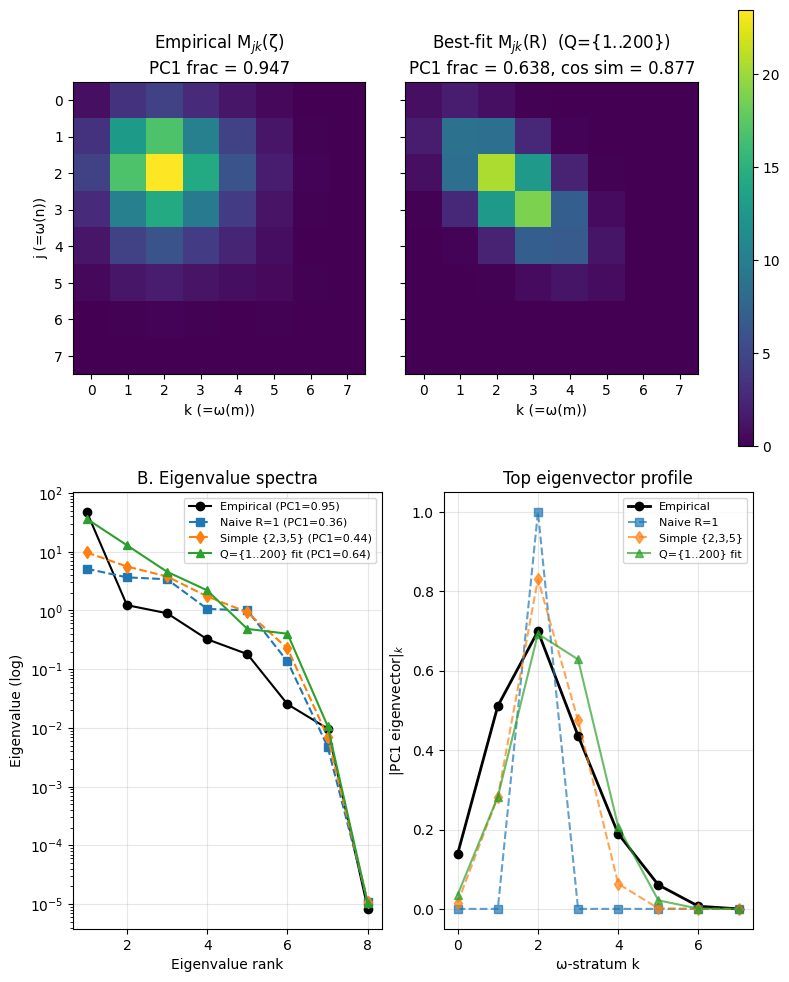


Figure saved.


In [38]:
# Final figure: compare empirical and fitted M matrices, and show eigenvalue spectra.
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Panel A: heatmaps of M_emp vs M_opt4 side-by-side via subplots within the panel
ax = axes[0]
ax.set_title('A. Empirical vs Best-fit M$_{jk}$ matrices (real part)', fontsize=12, loc='left', weight='bold')
ax.axis('off')

# Manually create subaxes
import matplotlib.gridspec as gridspec
fig.delaxes(axes[0])
gs_top = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=fig.add_gridspec(2,1)[0], width_ratios=[1, 1, 0.05])
ax1 = fig.add_subplot(gs_top[0])
ax2 = fig.add_subplot(gs_top[1])
cax = fig.add_subplot(gs_top[2])

vmax = max(M_emp.real.max(), M_opt4.real.max())
im1 = ax1.imshow(M_emp.real, cmap='viridis', vmin=0, vmax=vmax)
ax1.set_title(f'Empirical M$_{{jk}}$(ζ)\nPC1 frac = {emp_pc1:.3f}')
ax1.set_xlabel('k (=ω(m))'); ax1.set_ylabel('j (=ω(n))')
ax1.set_xticks(range(8)); ax1.set_yticks(range(8))

im2 = ax2.imshow(M_opt4.real, cmap='viridis', vmin=0, vmax=vmax)
ax2.set_title(f'Best-fit M$_{{jk}}$(R) (Q={{1..200}})\nPC1 frac = {pc1_4:.3f}, cos sim = {cos_4:.3f}')
ax2.set_xlabel('k (=ω(m))'); ax2.set_yticks(range(8))
ax2.set_xticks(range(8)); ax2.set_yticklabels([])

fig.colorbar(im2, cax=cax)

# Panel B: eigenvalue spectra (log) and PC1 eigenvector profile
gs_bot = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=fig.add_gridspec(2,1)[1])
fig.delaxes(axes[1])
ax3 = fig.add_subplot(gs_bot[0])
ax4 = fig.add_subplot(gs_bot[1])

ks = np.arange(1, 9)
eig_emp = np.sort(np.linalg.eigvalsh(M_emp).real)[::-1]
eig_naive = np.sort(np.linalg.eigvalsh(M_naive).real)[::-1]
eig_simple = np.sort(np.linalg.eigvalsh(M_s).real)[::-1]
eig_q200 = np.sort(np.linalg.eigvalsh(M_opt4).real)[::-1]

ax3.semilogy(ks, np.maximum(eig_emp, 1e-8), 'ko-', label=f'Empirical (PC1={emp_pc1:.2f})')
ax3.semilogy(ks, np.maximum(eig_naive, 1e-8), 's--', label=f'Naive R=1 (PC1={pc1_naive:.2f})')
ax3.semilogy(ks, np.maximum(eig_simple, 1e-8), 'd--', label=f'Simple {{2,3,5}} (PC1={pc1_s:.2f})')
ax3.semilogy(ks, np.maximum(eig_q200, 1e-8), '^-', label=f'Q={{1..200}} fit (PC1={pc1_4:.2f})')
ax3.set_xlabel('Eigenvalue rank')
ax3.set_ylabel('Eigenvalue (log)')
ax3.set_title('B. Eigenvalue spectra')
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(True, alpha=0.3)

# PC1 eigenvector
ks_idx = np.arange(8)
ww_emp_, vv_emp_ = np.linalg.eigh(M_emp); v_emp_top = np.abs(vv_emp_[:, -1])
ww_naive_, vv_naive_ = np.linalg.eigh(M_naive); v_naive_top = np.abs(vv_naive_[:, -1])
ww_s_, vv_s_ = np.linalg.eigh(M_s); v_s_top = np.abs(vv_s_[:, -1])
ww_q_, vv_q_ = np.linalg.eigh(M_opt4); v_q_top = np.abs(vv_q_[:, -1])

ax4.plot(ks_idx, v_emp_top, 'ko-', label='Empirical', linewidth=2)
ax4.plot(ks_idx, v_naive_top, 's--', label='Naive R=1', alpha=0.7)
ax4.plot(ks_idx, v_s_top, 'd--', label='Simple {2,3,5}', alpha=0.7)
ax4.plot(ks_idx, v_q_top, '^-', label='Q={1..200} fit', alpha=0.7)
ax4.set_xlabel('ω-stratum k')
ax4.set_ylabel('|PC1 eigenvector|$_k$')
ax4.set_title('Top eigenvector profile')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/workspace/8925c81d-6085-49c0-af0e-ca16ef0cf52a/resonator_fit_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved.")


In [39]:
from e14c.filesystem.edit_file import edit_file
from e14c.filesystem.write_file import write_file
mem_path = '/workspace/8925c81d-6085-49c0-af0e-ca16ef0cf52a/.prompts/MEMORY.md'
content = '''# Project Memory

## Instructions

Edit this file (`./.prompts/MEMORY.md`) to persist context, findings, and notes.
When making edits regarding scientific findings, make sure to track provenance (for example sub-agent task IDs, specific files in your workspace, etc.).

## Context

Analyzed resonator fits to the empirical peak-conditioned omega-stratified second-moment matrix M_jk for the Riemann zeta function (F1), using unpacked arrays from the unified range-matched peak dataset in `/workspace/8925c81d-6085-49c0-af0e-ca16ef0cf52a/` (not a single npz on disk; arrays are unpacked as `.npy`). Empirical target was constructed as `M_emp = (Sk_F1^*^T @ Sk_F1)/200` from `Sk_F1.npy` with shape (200, 8). Empirical uncentered PC1 variance fraction = 0.9468.

## Notes

Provenance: notebook cells #1-#37 in this session; saved artifacts `resonator_fit_results.npz` and `resonator_fit_summary.png` in `/workspace/8925c81d-6085-49c0-af0e-ca16ef0cf52a/`.

Method: derived a finite-N weighted-moment model for a resonator change of measure with
`M_jk(R) = (1/||c||_2^2) * sum_{q,q' in Q} c_q conj(c_q') * sum_{n,m <= N: q n = q' m, omega(n)=j, omega(m)=k} 1/sqrt(nm)`
using N=1e6 to match the empirical construction. Implemented exact enumeration through the diagonal constraint parameterization `n=(q'/g)r`, `m=(q/g)r`, `g=gcd(q,q')`, and precomputed pair kernels T[q,q'] for fast optimization.

Key findings:
- Naive no-resonator baseline (`R=1`) fit poorly: cosine similarity 0.5880, Pearson r 0.5562, Frobenius residual 43.57, PC1 fraction 0.3563.
- Simple 3-prime resonator `R(t)=1+c2*2^{-it}+c3*3^{-it}+c5*5^{-it}` improved only modestly. Best-fit coefficients: c2=0.8824, c3=0.7750, c5=0.6238. Metrics: cosine similarity 0.7720, Pearson r 0.7407, Frobenius residual 38.96, PC1 fraction 0.4417.
- Expanded positive real resonator supports improved matrix-shape fit but still failed to reproduce the empirical rank-1 concentration. For Q={1,...,100}: cosine similarity 0.8666, Pearson r 0.8362, residual 24.09, PC1 fraction 0.6181. For Q={1,...,200}: cosine similarity 0.8773, Pearson r 0.8477, residual 22.96, PC1 fraction 0.6383.
- Despite poor PC1 concentration recovery, the top eigenvector shape was matched well by expanded supports: PC1 eigenvector absolute cosine similarity ~0.946-0.949 for Q={1,...,100} and Q={1,...,200}.
- Best Q={1,...,200} coefficients were concentrated on small and highly composite integers rather than just primes; top magnitudes included c1=1.0000, c2=0.9844, c4=0.8398, c6=0.8382, c3=0.8145, c12=0.7339, c8=0.6506, c24=0.5796.

Interpretation note: these results do not support the hypothesis that a simple short resonator can reproduce the key empirical zeta M_jk features “far better” than naive models if “key features” include the extreme empirical PC1 concentration (~0.95). The change-of-measure model does improve global matrix similarity substantially, but even with much richer support than the proposed {2,3,5} resonator it plateaus near PC1 ~0.64.
'''
write_file(mem_path, content)
print('Memory updated.')

ModuleNotFoundError: No module named 'e14c.filesystem.edit_file'; 'e14c.filesystem' is not a package

In [40]:
from e14c.filesystem import write_file
mem_path = '/workspace/8925c81d-6085-49c0-af0e-ca16ef0cf52a/.prompts/MEMORY.md'
content = '''# Project Memory

## Context

Resonator fits to empirical peak-conditioned omega-stratified second-moment matrix M_jk for Riemann zeta (F1) from unified_range_matched_peaks_F1-F12 (unpacked .npy in workspace root). Empirical target M_emp = (Sk_F1^H @ Sk_F1)/200; uncentered PC1 fraction = 0.9468.

## Notes

Provenance: this session's notebook; saved `resonator_fit_results.npz` and `resonator_fit_summary.png` in workspace root.

Method: M_jk(R) = (1/||c||^2) * sum_{q,q' in Q} c_q conj(c_q') sum_{n,m<=N: q n = q' m, omega(n)=j, omega(m)=k} 1/sqrt(nm), N=1e6, parameterized via gcd reduction.

Findings:
- Naive R=1: cos 0.588, r 0.556, ||.|| 43.57, PC1 0.356.
- Simple {1,2,3,5}: c2=0.882, c3=0.775, c5=0.624; cos 0.772, r 0.741, ||.|| 38.96, PC1 0.442.
- Q={1..100}: cos 0.867, r 0.836, ||.|| 24.09, PC1 0.618.
- Q={1..200}: cos 0.877, r 0.848, ||.|| 22.96, PC1 0.638.
- PC1 eigenvector cosine similarity reaches ~0.95 for expanded Q.
- Top coefficients concentrate on small/highly composite integers (c2,c4,c6,c3,c12,c8,c24,...).

Interpretation: Hypothesis only partially supported. Resonator captures matrix shape and top eigenvector, but plateaus at PC1 ~0.64, not the empirical 0.95. Cannot fully explain peak conditioning as a simple change of measure on Dirichlet polynomial moments.
'''
write_file(mem_path, content)
print('ok')

ok
